# Testing Notebook

# Ignore Trainig and Validation Accuracy, those are not objective truth measruements they are more just a guage to see how far the model is from the actual postion of the car
# Also ignore those metrics for the funciton reportFinalMetrics

In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import config as cfg
import os

import torch
from torch import nn
from torch.utils.data import DataLoader

from Data.data_loading import load_and_preprocess_data, create_tensor_from_dataframe, create_sequences, create_dataloaders 
from Training.train_matt import Trainer
from Training.basicEval import plotLoss, plotAccuracy, reportFinalMetrics, reportMultiFinalMetrics, plotMultiAccuracy, plotMultiLoss, test_model
from NextNet.model_split import FrameTransformer, print_model_info

from Training.customLoss import ADELoss, FDELoss, RMSELoss, PaddedMSELoss

Using GPU


In [2]:
root_dir = os.getcwd()  # Use current working directory as root
data_dir = os.path.join(root_dir, 'Data')
csv_dir = os.path.join(data_dir, 'csv')
csv_file = os.path.join(csv_dir, 'trimmed_IMG_4097_detections.csv')

print("Data directory: ", data_dir)
print("CSV directory: ", csv_dir)
print("CSV file: ", csv_file)


model_dir = os.path.join(root_dir, 'Model')
save_model_dir = os.path.join(model_dir, 'Saved_Model')
print("Model directory: ", model_dir)
print("Saved model directory: ", save_model_dir)
model_name = 'mse_model.pth'


Data directory:  /home/jaskin/Deep-Learning-Project/Data
CSV directory:  /home/jaskin/Deep-Learning-Project/Data/csv
CSV file:  /home/jaskin/Deep-Learning-Project/Data/csv/trimmed_IMG_4097_detections.csv
Model directory:  /home/jaskin/Deep-Learning-Project/Model
Saved model directory:  /home/jaskin/Deep-Learning-Project/Model/Saved_Model


In [3]:
ADE = ADELoss()
FDE = FDELoss()
RMSE = RMSELoss()
PADDEDMSE = PaddedMSELoss()

In [4]:
df, transformer_max_ids_per_frame, frame_scaler, feature_scaler = load_and_preprocess_data(csv_folder=csv_dir)

# 2. Create tensor from dataframe
all_data_tensor = create_tensor_from_dataframe(df, transformer_max_ids_per_frame)

# 3. Create input-output sequences
X, Y = create_sequences(all_data_tensor)

# 4. Create dataloaders for training and testing
train_loader, test_loader, train_prefetcher, test_prefetcher = create_dataloaders(X, Y)


All CSVs now have 599 frames after trimming
Minimum records per ID: 3
Average records per ID: 1763.55
Maximum records per ID: 3209

Minimum IDs (Vehicles) per frame: 5
Average IDs (Vehicles) per frame: 14.34
Maximum IDs (Vehicles) per frame: 20

Before normalization:
X range: 10.0000 to 1911.0000
Y range: 160.0000 to 1031.0000
Height range: 11.0000 to 442.0000
Width range: 15.0000 to 974.0000
Frame range: 0.0000 to 607.0000

After normalization:
X range: 0.0000 to 20.0000
Y range: 0.0000 to 20.0000
Height range: 0.0000 to 5.0000
Width range: 0.0000 to 5.0000
Frame range: 0.0000 to 5.0000
Determined tensor ID dimension size based on max(ID_Norm): 20
All data tensor shape: torch.Size([6, 599, 20, 5])


# MSE

In [5]:
# Adjust the hidden_size and sequence_length to match the input tensor dimensions
model = FrameTransformer(
        input_feature_size=cfg.NUM_INPUT_FEATURES, 
        num_ids=transformer_max_ids_per_frame, 
        sequence_length=X.size(1),  
        prediction_length=cfg.PREDICTION_LENGTH,
        hidden_size=64,  
        num_heads=cfg.NUM_HEADS,
        dropout_rate=cfg.DROPOUT_RATE
)


In [6]:
retrain_model = True
if retrain_model:
    trainScript = Trainer(model, train_loader, test_loader)

    trainScript.earlyStop(enable=True, patience=30, delta=0.01)
    train_losses1, val_losses1, train_accs1, val_accs1, epoch_times1 = trainScript.train(
        num_epochs=cfg.EPOCHS, 
        learningRate=cfg.LEARNING_RATE, 
        criterion=PADDEDMSE, 
        optimizer=torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
    )
    # Ensure the directory exists before saving the model
    os.makedirs(save_model_dir, exist_ok=True)
    model_file_path = os.path.join(save_model_dir, 'mse_model_5s.pth')  # Add a file name
    print("Saving model to: ", model_file_path)
    trainScript.save_model(model, model_file_path)
else:
    model = torch.load(os.path.join(save_model_dir, model_name), weights_only=False)


Training on device: cuda


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 2/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

...

Epoch 49/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 49/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 50/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]


Training complete in 297.53 seconds, or 4.96 minutes
Total epochs run: 50
Average time per epoch: 5.95 seconds
Inference time per batch: 0.08 seconds
Final Training Loss: 14.1738
Final Validation Loss: 20.2202
Final Training Accuracy: 1.78%
Final Validation Accuracy: 0.27%
Saving model to:  /home/jaskin/Deep-Learning-Project/Model/Saved_Model/mse_model_5s.pth


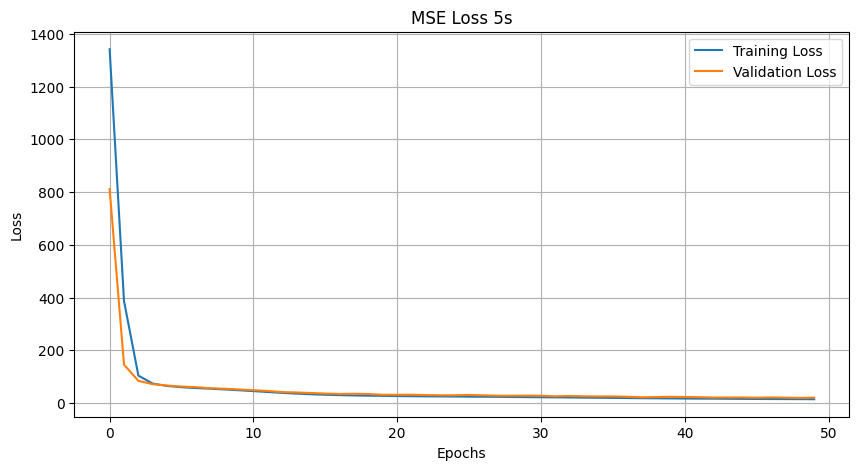

Predicted shape: (564, 30, 20, 2)
Denormalizing Y
Y_flat shape: (338400, 2)
Y_denorm_flat shape: (338400, 2)
Y_denorm shape: (564, 30, 20, 2)
Y_denorm: [[1455.9325    346.56784 ]
 [ 624.08856   262.2414  ]
 [ 887.6785    222.26868 ]
 [1863.3826    408.86063 ]
 [ 838.4977    444.39752 ]
 [ 752.2409    363.18286 ]
 [1163.4564    665.2164  ]
 [ 470.4598    293.44803 ]
 [ 897.0405    415.58185 ]
 [ 325.40918   242.54944 ]
 [1689.0253    389.8629  ]
 [ 485.03574   237.07866 ]
 [ 527.32825   165.2557  ]
 [ 621.1711    209.83876 ]
 [ 729.16986   276.85342 ]
 [ 199.36693   335.53262 ]
 [ 195.09259   229.47952 ]
 [ 227.12033   144.32286 ]
 [-452.42877   -30.265007]
 [  34.3411     60.514267]]
Denormalizing Y
Y_flat shape: (338400, 2)
Y_denorm_flat shape: (338400, 2)
Y_denorm shape: (564, 30, 20, 2)
Y_denorm: [[1382.        320.      ]
 [ 569.00006   268.      ]
 [ 812.99994   228.      ]
 [1789.        387.      ]
 [ -85.049995  116.450005]
 [ 691.        318.      ]
 [1019.99994   600.      ]


In [12]:
plotLoss(train_losses1, val_losses1, 'MSE Loss 5s')
#plotAccuracy(train_accs1, val_accs1)

test_model(model, test_loader,PADDEDMSE, feature_scaler)

# ADE

In [8]:
trainScript = Trainer(model, train_loader, test_loader)

trainScript.earlyStop(enable=True, patience=30, delta=0.01)
train_losses2, val_losses2, train_accs2, val_accs2, epoch_times2 = trainScript.train(
    num_epochs=cfg.EPOCHS, 
    learningRate=cfg.LEARNING_RATE, 
    criterion=ADE, 
    optimizer=torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
)


Training on device: cuda


Training Progress:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

RuntimeError: The size of tensor a (20) must match the size of tensor b (2) at non-singleton dimension 3

In [ ]:
# Ensure the directory exists before saving the model
os.makedirs(save_model_dir, exist_ok=True)
model_file_path = os.path.join(save_model_dir, 'ADE_model.pth')  # Add a file name
print("Saving model to: ", model_file_path)
trainScript.save_model(model, model_file_path)

In [ ]:
plotLoss(train_losses2, val_losses2)
plotAccuracy(train_accs2, val_accs2)
reportFinalMetrics(train_losses2, val_losses2, train_accs2, val_accs2, epoch_times2)

# FDE

In [ ]:
trainScript = Trainer(model, train_loader, test_loader)

trainScript.earlyStop(enable=True, patience=30, delta=0.01)
train_losses3, val_losses3, train_accs3, val_accs3, epoch_times3 = trainScript.train(
    num_epochs=cfg.EPOCHS, 
    learningRate=cfg.LEARNING_RATE, 
    criterion=FDE, 
    optimizer=torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
)

In [ ]:
# Ensure the directory exists before saving the model
os.makedirs(save_model_dir, exist_ok=True)
model_file_path = os.path.join(save_model_dir, 'FDE_model.pth')  # Add a file name
print("Saving model to: ", model_file_path)
trainScript.save_model(model, model_file_path)

In [ ]:
plotLoss(train_losses3, val_losses3)
plotAccuracy(train_accs3, val_accs3)
reportFinalMetrics(train_losses3, val_losses3, train_accs3, val_accs3, epoch_times3)

# RSME

In [ ]:
trainScript = Trainer(model, train_loader, test_loader)

trainScript.earlyStop(enable=True, patience=30, delta=0.01)
train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4 = trainScript.train(
    num_epochs=cfg.EPOCHS, 
    learningRate=cfg.LEARNING_RATE, 
    criterion=RMSE, 
    optimizer=torch.optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
)

In [ ]:
# Ensure the directory exists before saving the model
os.makedirs(save_model_dir, exist_ok=True)
model_file_path = os.path.join(save_model_dir, 'RSME_model.pth')  # Add a file name
print("Saving model to: ", model_file_path)
trainScript.save_model(model, model_file_path)

In [ ]:
plotLoss(train_losses4, val_losses4)
plotAccuracy(train_accs4, val_accs4)
reportFinalMetrics(train_losses4, val_losses4, train_accs4, val_accs4, epoch_times4)

# Combined Plots

In [ ]:
multi_train_losses = [train_losses1, train_losses2, train_losses3, train_losses4]
multi_val_losses = [val_losses1, val_losses2, val_losses3, val_losses4]
multi_train_accs = [train_accs1, train_accs2, train_accs3, train_accs4]
multi_val_accs = [val_accs1, val_accs2, val_accs3, val_accs4]
multi_epoch_times = [epoch_times1, epoch_times2, epoch_times3, epoch_times4]

model_names = ['MSE', 'ADE', 'FDE', 'RMSE']

In [ ]:
plotMultiLoss(model_names, multi_train_losses, multi_val_losses)
plotMultiAccuracy(model_names, multi_train_accs, multi_val_accs)